<h1>Imports & Setup</h1>


In [18]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)


<h1>Data Loading & Preprocessing</h1>

In [19]:
df = pd.read_csv("../dataset/medical_insurance_encoded.csv")
print(f"Dataset shape: {df.shape}")
display(df.head())

X = df.drop("charges", axis=1)
y = df["charges"]
y_log = np.log1p(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

Dataset shape: (1337, 16)


,cat__sex_male,cat__smoker_yes,cat__region_northwest,cat__region_southeast,cat__region_southwest,remainder__age,remainder__bmi,remainder__children,remainder__smoker_bmi,remainder__age_squared,remainder__age_smoker,remainder__is_underweight,remainder__is_obese,remainder__obese_smoker,remainder__children_smoker,charges
0,0.0,1.0,0.0,0.0,1.0,19.0,27.900,0.0,27.9,361.0,19.0,0.0,0.0,0.0,0.0,16884.92400
1,1.0,0.0,0.0,1.0,0.0,18.0,33.770,1.0,0.0,324.0,0.0,0.0,1.0,0.0,0.0,1725.55230
2,1.0,0.0,0.0,1.0,0.0,28.0,33.000,3.0,0.0,784.0,0.0,0.0,1.0,0.0,0.0,4449.46200
3,1.0,0.0,1.0,0.0,0.0,33.0,22.705,0.0,0.0,1089.0,0.0,0.0,0.0,0.0,0.0,21984.47061
4,1.0,0.0,1.0,0.0,0.0,32.0,28.880,0.0,0.0,1024.0,0.0,0.0,0.0,0.0,0.0,3866.85520


<h1>Base Model Training</h1>


In [20]:
base_model = RandomForestRegressor(random_state=42)
base_model.fit(X_train, y_train)

y_pred_log_base = base_model.predict(X_test)
y_pred_base = np.expm1(y_pred_log_base)

y_test_actual = np.expm1(y_test)

mae = mean_absolute_error(y_test_actual, y_pred_base)
mse = mean_squared_error(y_test_actual, y_pred_base)
rmse = root_mean_squared_error(y_test_actual, y_pred_base)
r2 = r2_score(y_test_actual, y_pred_base)

print("--- Base Model Performance ---")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)


--- Base Model Performance ---
MAE : 2105.9366802480968
MSE : 19575492.088954005
RMSE: 4424.419972036335
R²  : 0.8934702253713069


<h1>Hyperparameter Tuning</h1>

In [21]:
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 5, 6, 8, None],
    "min_samples_split": [5, 10, 20,],
    "min_samples_leaf": [4, 8, 16],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2"
)

grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)

Best parameters found:  {'max_depth': 4, 'min_samples_leaf': 8, 'min_samples_split': 20, 'n_estimators': 200}


<h1>Final Model Training & Cross-Validation</h1>

In [22]:
best_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=8,
    random_state=42
)

best_model.fit(X_train, y_train)

y_pred_log_best = best_model.predict(X_test)
y_pred_best = np.expm1(y_pred_log_best)
y_test_actual = np.expm1(y_test)

mae = mean_absolute_error(y_test_actual, y_pred_best)
mse = mean_squared_error(y_test_actual, y_pred_best)
rmse = root_mean_squared_error(y_test_actual, y_pred_best)
r2 = r2_score(y_test_actual, y_pred_best)

print("--- Tuned Best Model Performance ---")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

cv_scores = cross_val_score(best_model, X, y_log, cv=5, scoring='r2')
print("R² per fold:", cv_scores)
print(f"Mean R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

--- Tuned Best Model Performance ---
MAE : 2024.1239321875867
MSE : 18234629.68036206
RMSE: 4270.202533880806
R²  : 0.9007671949466459
R² per fold: [0.87361087 0.73067743 0.88746937 0.83862966 0.80975997]
Mean R²: 0.8280 ± 0.0557


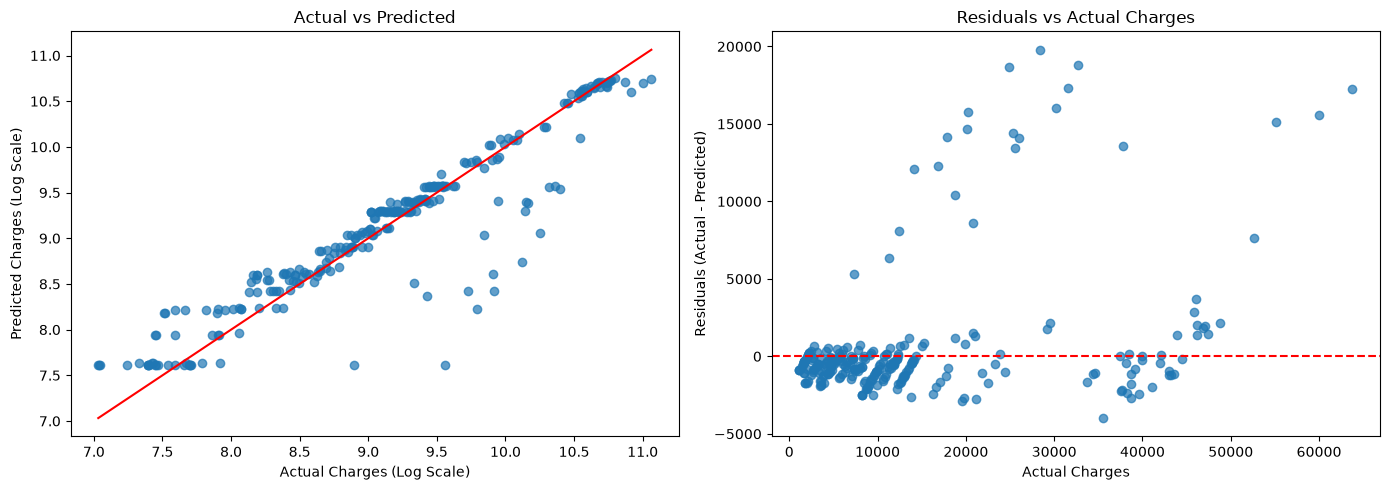

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted (Log Scale)
axes[0].scatter(y_test, y_pred_log_best, alpha=0.7)
axes[0].plot(
    [y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red"
)
axes[0].set_xlabel("Actual Charges (Log Scale)")
axes[0].set_ylabel("Predicted Charges (Log Scale)")
axes[0].set_title("Actual vs Predicted")

# Plot 2: Residuals Plot (Original Scale)
residuals = y_test_actual - y_pred_best
axes[1].scatter(y_test_actual, residuals, alpha=0.7)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Actual Charges")
axes[1].set_ylabel("Residuals (Actual - Predicted)")
axes[1].set_title("Residuals vs Actual Charges")

plt.tight_layout()
plt.show()

<h1>Feature Importance Analysis</h1>

In [24]:
importances = pd.Series(
    best_model.feature_importances_, index=best_model.feature_names_in_
).sort_values(ascending=False)

print("Feature Importances:")
print(importances)

Feature Importances:
remainder__smoker_bmi         0.379628
remainder__age_squared        0.203126
remainder__age                0.200159
remainder__age_smoker         0.101383
cat__smoker_yes               0.049267
remainder__children           0.043577
remainder__bmi                0.016246
remainder__obese_smoker       0.002938
remainder__is_obese           0.002783
cat__region_southwest         0.000398
cat__region_southeast         0.000185
cat__region_northwest         0.000150
cat__sex_male                 0.000144
remainder__children_smoker    0.000016
remainder__is_underweight     0.000000
dtype: float64


<h1>Export Model</h1>

In [25]:
joblib.dump(best_model, "../models/random_forest_model.pkl")

['../models/random_forest_model.pkl']